# 11. Per-base DNA attribution

Prediction gives a number; **attribution** explains it. For a chosen cell state, Bolero collapses its
conditional-LoRA weights into a plain DNA→accessibility model and runs
[captum](https://captum.ai/)'s `InputXGradient` on it: the gradient of the predicted peak signal with
respect to the one-hot input, times the input. The result is a **per-base contribution score** — how
much each nucleotide pushes the prediction up or down — which reads as a sequence logo of the motifs
the model is using.

This page shows **how to ask for attribution over a region** and **what the task writes out**.

> **This page uses the `bolerodata` model zoo**, so it runs in the lab environment; the committed
> outputs are what you would see. The mechanics are the same for any trained model, including the
> self-contained one from the [prediction page](09_prediction_task.ipynb).

## Setup

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from bolero import init
from bolero.pl.seqlogo import AttributionPlotter
from bolerodata import MODELS

init(num_cpus=16, object_store_memory_gb=48)

2026-07-13 20:30:50,876	INFO worker.py:1781 -- Started a local Ray instance.


## Model and cell state

Attribution is **cell-state-specific**: the model is collapsed onto one pseudobulk's embedding before
the gradient is taken. We load the atlas accessibility model conditioned on brain cell states and pick
a single cell state to attribute for (`pseudobulk_ids`).

In [2]:
model = MODELS["Borzoi10M"]
model.dataset = "HumanBrainDev"

CELL_STATE = "group6-pseudobulk3"
pred = model.create_predictor(nosignal=True, pseudobulk_ids=[CELL_STATE])
print("attributing for cell state:", CELL_STATE, "of", model.dataset.name)

attributing for cell state: group6-pseudobulk3 of HumanBrainDev


## The input: which regions to attribute

`regions_per_pseudobulk` says *where* to compute attribution. It accepts either:

- a **BED / DataFrame** of regions (`Chromosome`, `Start`, `End`) — used for every cell state. Each is
  centered and padded to the model's 524,288 bp window; the center 1,024 bp is scored.
- a **`dict{pseudobulk_id: regions}`** — different regions per cell state.

A real run passes many peaks (e.g. `DATASETS[...].peak_bed_path`). Here we attribute one example ATAC
peak so the demo is quick.

In [3]:
EXAMPLE_PEAK = "chr10:120505130-120505630"     # an accessible ATAC peak
chrom, coords = EXAMPLE_PEAK.split(":")
start, end = map(int, coords.split("-"))
regions = pd.DataFrame({"Chromosome": [chrom], "Start": [start], "End": [end]})
regions

,Chromosome,Start,End
0,chr10,120505130,120505630


## Run the attribution task

In [4]:
pred.attribution_task(
    "attribution_task_output",
    regions_per_pseudobulk=regions,   # or a dict {pseudobulk_id: regions} for per-state regions
    mode="attribution",
    batch_size=4,
)

mode:  attribution
qtl_type:  None
Save keys: ['region', 'pseudobulk_id', 'region_name', 'seqlets_info', 'seqlets_dna', 'seqlets_attr', 'seqlets_attr1d', '__dna__:attr', '__dna__:attr_seq']
Saving batches to /large_storage/zhoulab/hanliu/pkg/liuhlab/bolero/docs/tutorials/prediction/attribution_task_output/batch


Loading base model weights from: /home/hanliu/data/wmb/model/Borzoi/flashzoi_checkpoints/fold_0.renamed.pt


Model does not have gene_count_output_head, skip
Loading checkpoint from /large_storage/zhoulab/hanliu/250907-MultiDatasetModel/Bolero10M/model/251103-Bolero10M_atac_fold0-final.lora.best_checkpoint.pt


Dataloader Batch Schema:
- HumanBrainDev.MetaCell:cov_scale: <class 'torch.Tensor'> torch.Size([1]) torch.float64 cuda:0
- __conditionemb__: <class 'torch.Tensor'> torch.Size([1, 1, 3]) torch.float32 cuda:0
- __dna__: <class 'torch.Tensor'> torch.Size([1, 4, 524288]) torch.uint8 cuda:0
- __dna__:attr: <class 'numpy.ndarray'> (1, 4, 1024) float32
- __dna__:attr_seq: <class 'numpy.ndarray'> (1, 4, 1024) float32
- __embedding__: <class 'torch.Tensor'> torch.Size([1, 60]) torch.float32 cuda:0
- full_attr1d: <class 'scipy.sparse._coo.coo_matrix'> (1, 1024)
- full_attr_list: <class 'list'> 1
- pseudobulk_id: <class 'str'> ensemble|data:data-0
- reference: <class 'torch.Tensor'> torch.Size([1, 16384]) torch.float32 cuda:0
- region: <class 'numpy.ndarray'> (1,) <U25
- region_name: <class 'numpy.ndarray'> (1,) <U25
- seqlets_attr: <class 'numpy.ndarray'> (7, 4, 50) float16
- seqlets_attr1d: <class 'numpy.ndarray'> (7, 50) float16
- seqlets_dna: <class 'numpy.ndarray'> (7, 4, 50) bool
- seqlets_

## What the task wrote

The task saves a **region-level** and a **seqlet-level** view, each as a feather index + a zarr array:

- **`attribution_regions.feather`** — the coordinates of each attributed region and the
  `pseudobulk_id` (cell state) it was computed for.
- **`region_attribution_and_seq.zarr`** — `__dna__:attr` = the per-base contribution scores with dims
  `(region, base, position)` = `(N, 4, 1024)`, and `__dna__:attr_seq` = the matching one-hot sequence.
- **`seqlets_info.feather` / `seqlets_attribution_and_seq.zarr`** — the high-attribution stretches
  ("seqlets") that Bolero automatically calls out of each region as candidate motif instances.

In [5]:
out = "attribution_task_output"
print("output files:", sorted(os.listdir(out)))

attr_regions = pd.read_feather(f"{out}/attribution_regions.feather")
print("\nattribution_regions.feather:", attr_regions.shape)
print("cell states:", list(attr_regions["pseudobulk_id"].unique()))

ds = xr.open_zarr(f"{out}/region_attribution_and_seq.zarr")
print("__dna__:attr    ", ds["__dna__:attr"].dims, tuple(ds["__dna__:attr"].shape))
print("__dna__:attr_seq", ds["__dna__:attr_seq"].dims, tuple(ds["__dna__:attr_seq"].shape))

seqlets = pd.read_feather(f"{out}/seqlets_info.feather")
print("\nseqlets_info.feather:", seqlets.shape)
seqlets.head(3)

output files: ['attribution_regions.feather', 'batch', 'config.joblib.gz', 'region_attribution_and_seq.zarr', 'seqlets_attribution_and_seq.zarr', 'seqlets_info.feather']

attribution_regions.feather: (1, 6)
cell states: ['group6-pseudobulk3']
__dna__:attr     ('region', 'base', 'position') (1, 4, 1024)
__dna__:attr_seq ('region', 'base', 'position') (1, 4, 1024)

seqlets_info.feather: (7, 10)


,start,end,attribution,p-value,flank_start,flank_end,attr_region,attr_region_chrom,attr_region_start,pseudobulk_id
seqlet,,,,,,,,,,
0,432,443,19.802734,0.000194,412,462,chr10:120505130-120505630,chr10,120504868,group6-pseudobulk3
1,380,385,6.085938,0.000227,357,407,chr10:120505130-120505630,chr10,120504868,group6-pseudobulk3
2,690,698,11.014648,0.000278,669,719,chr10:120505130-120505630,chr10,120504868,group6-pseudobulk3


## Plot: a per-base attribution logo

We pull the region's `(4, 1024)` attribution and one-hot sequence, zoom into the central window, and
draw the logo. Letter height is the base's contribution; tall stacks are the sequence the model
"reads" (a motif). `AttributionPlotter` takes the attribution `(4, L)` and the sequence `(L, 4)`.

[Text(0.5, 1.0, 'chr10:120505130-120505630   |   group6-pseudobulk3'),
 Text(0.5, 0, 'position (center +/- 100 bp)'),
 Text(0, 0.5, 'attribution')]

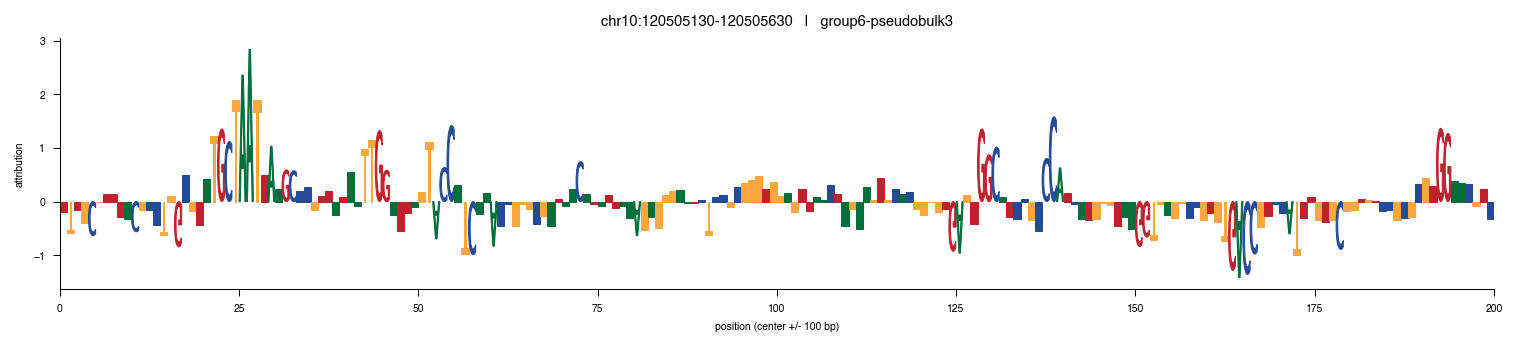

In [6]:
idx = 0
attr = ds["__dna__:attr"].isel(region=idx).values.astype(float)        # (4, 1024)
seq = ds["__dna__:attr_seq"].isel(region=idx).values.astype(float)      # (4, 1024)

flank = 100
center = attr.shape[1] // 2
sl = slice(center - flank, center + flank)
attr_win = attr[:, sl] - attr[:, sl].mean(axis=0)   # mean-normalize per position
seq_win = seq.T[sl]                                  # (2*flank, 4)

fig, ax = plt.subplots(figsize=(10, 2.2), dpi=150, constrained_layout=True)
AttributionPlotter("hg38").plot(ax=ax, attribution=attr_win, sequence=seq_win, rectangle_ratio=0.75)
ax.set(title=f"{EXAMPLE_PEAK}   |   {CELL_STATE}", xlabel=f"position (center +/- {flank} bp)",
       ylabel="attribution")

## Attributing a variant (ref vs alt)

The same task can attribute the **two alleles of a variant** instead of a plain region: pass the
caQTL/eQTL table (built as on the [variant-effect page](10_qtl_task.ipynb)) and a `qtl_type`. The
output zarr then carries a `genotype` axis (ref / alt), and the **difference** `ref − alt` of the
per-base attribution shows the motif a SNV creates or destroys:

```python
pred.attribution_task(
    "variant_attr_output",
    regions_per_pseudobulk=None,        # regions are taken from the variant table
    qtl_table="variant_caqtl_format.feather",
    qtl_type="caqtl",
)

ds = xr.open_zarr("variant_attr_output/region_attribution_and_seq.zarr")
ref_attr, alt_attr = ds["__dna__:attr"].sel(genotype=["ref", "alt"])
delta = ref_attr - alt_attr             # per-base attribution change from the variant
```

Plot `ref_attr`, `alt_attr`, and `delta` as three stacked logos to read the allelic motif change.

---

Across these three pages you have run the same trained model in its three main modes — **predict** a
track, **score** a variant, and **attribute** a prediction to individual bases — and, in each case,
seen exactly what to feed in and what comes out. From here, the attribution outputs feed the motif and
footprinting tools in `bolero.tl.motif` / `bolero.tl.footprint`.